Dataset Shape: (20640, 9)
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  

Linear Regression
------------------------------
RMSE: 0.6958701266963986
R² Score: 0.6304701499538703

Ridge Regression
------------------------------
RMSE: 0.6958746397143204
R² Score: 0.6304653568173932

Decision Tree
------------------------------
RMSE: 0.7160351551566977
R² Score: 0.6087432611240682

Model Comparison
               Model      RMSE  R2 Score
0  Linear Regressio

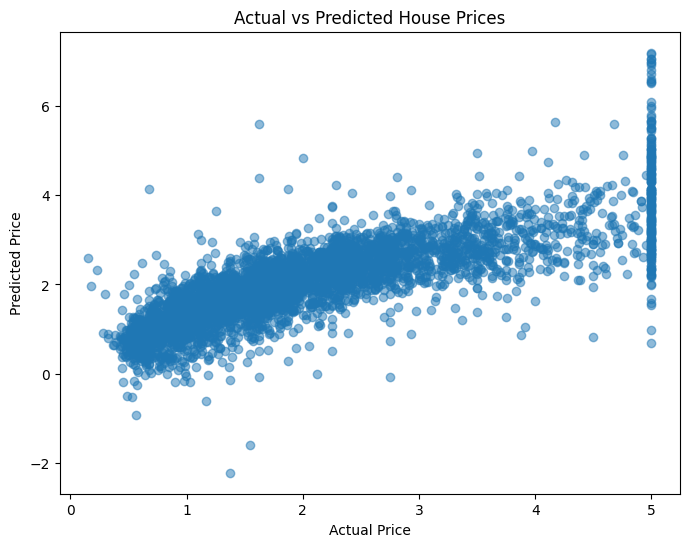

In [1]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Step 1: Load Dataset
housing = fetch_california_housing()

df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['Price'] = housing.target

print("Dataset Shape:", df.shape)
print(df.head())

# Step 2: Feature Engineering
df['Rooms_per_Household'] = df['AveRooms'] / df['HouseAge']
df['Bedrooms_per_Room'] = df['AveBedrms'] / df['AveRooms']
df['Population_per_Household'] = df['Population'] / df['AveOccup']

# Features and Target
X = df.drop('Price', axis=1)
y = df['Price']

# Step 3: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 4: Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 5: Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)

# Step 6: Ridge Regression
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)

ridge_pred = ridge_model.predict(X_test_scaled)

# Step 7: Decision Tree Regressor
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

# Step 8: Evaluation Function

def evaluate_model(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"\n{name}")
    print("-" * 30)
    print("RMSE:", rmse)
    print("R² Score:", r2)

    return [name, rmse, r2]

# Step 9: Compare Models
results = []

results.append(
    evaluate_model("Linear Regression", y_test, lr_pred)
)

results.append(
    evaluate_model("Ridge Regression", y_test, ridge_pred)
)

results.append(
    evaluate_model("Decision Tree", y_test, dt_pred)
)

# Step 10: Results Table
results_df = pd.DataFrame(
    results,
    columns=["Model", "RMSE", "R2 Score"]
)

print("\nModel Comparison")
print(results_df)

# Step 11: Best Model
best_model = results_df.loc[
    results_df["R2 Score"].idxmax()
]

print("\nBest Model:")
print(best_model)

# Step 12: Visualization

plt.figure(figsize=(8,6))
plt.scatter(y_test, ridge_pred, alpha=0.5)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()
